# 銀行の顧客ターゲティング

### 目次
**1. ライブラリのインポート**

**2. データの読み込み**

**3. 探索的データ分析**

**4. データの前処理**

**5. 学習・検証**

**6. 予測結果の提出**

## 1. ライブラリのインポート

In [91]:
!pip install japanize-matplotlib

In [92]:
import warnings #注意書き（警告）を画面に出さないようにします。
warnings.simplefilter('ignore')

import pandas as pd #表形式のデータ（Excelのようなデータ）を扱うための最強ツール
import numpy as np #数値計算を高速に行うためのライブラリ
import seaborn as sns #matplotlibをベースにした、より綺麗で高度な統計グラフを簡単に描くためのライブラリ
import matplotlib.pyplot as plt #Pythonのグラフ描画の基本ライブラリです。
import japanize_matplotlib #グラフ内で日本語が文字化け（□になる）してしまうのを防ぎ、日本語を表示できるようにします
%matplotlib inline
  #実行直後にグラフをインライン表示させるための命令 今はなくてもインラインできる

from sklearn.model_selection import train_test_split #持っているデータを「学習用」と「テスト用（答え合わせ用）」に分ける機能

from sklearn.ensemble import RandomForestClassifier #ランダムフォレストという機械学習モデルを使用する

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix #作ったAIがどれくらい賢いか測定するための指標たちです。
#accuracy_score: 正解率。単純に何％当たったか。confusion_matrix: 混合行列。どのパターンで間違えたか（「やる」と予想して「やらなかった」など）の詳細表。roc_curve / roc_auc_score: 予測の「自信（確率）」を考慮した評価指標。分類モデルの性能を総合的に判断するのに使います。
from sklearn.preprocessing import StandardScaler #データの値を「平均0、標準偏差1」に変換（スケーリング）します
from sklearn.model_selection import GridSearchCV

## 2. データの読み込み

In [93]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/データ解析/signate/銀行/data

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/データ解析/signate/銀行/data


In [94]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [95]:
print('train shape', train.shape)
train.info()

train shape (27128, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27128 entries, 0 to 27127
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         27128 non-null  int64 
 1   age        27128 non-null  int64 
 2   job        27128 non-null  object
 3   marital    27128 non-null  object
 4   education  27128 non-null  object
 5   default    27128 non-null  object
 6   balance    27128 non-null  int64 
 7   housing    27128 non-null  object
 8   loan       27128 non-null  object
 9   contact    27128 non-null  object
 10  day        27128 non-null  int64 
 11  month      27128 non-null  object
 12  duration   27128 non-null  int64 
 13  campaign   27128 non-null  int64 
 14  pdays      27128 non-null  int64 
 15  previous   27128 non-null  int64 
 16  poutcome   27128 non-null  object
 17  y          27128 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 3.7+ MB


In [96]:
print('test shape', test.shape)
test.info()

test shape (18083, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18083 entries, 0 to 18082
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         18083 non-null  int64 
 1   age        18083 non-null  int64 
 2   job        18083 non-null  object
 3   marital    18083 non-null  object
 4   education  18083 non-null  object
 5   default    18083 non-null  object
 6   balance    18083 non-null  int64 
 7   housing    18083 non-null  object
 8   loan       18083 non-null  object
 9   contact    18083 non-null  object
 10  day        18083 non-null  int64 
 11  month      18083 non-null  object
 12  duration   18083 non-null  int64 
 13  campaign   18083 non-null  int64 
 14  pdays      18083 non-null  int64 
 15  previous   18083 non-null  int64 
 16  poutcome   18083 non-null  object
dtypes: int64(8), object(9)
memory usage: 2.3+ MB


In [97]:
display(train.head(), test.head())

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,1,39,blue-collar,married,secondary,no,1756,yes,no,cellular,3,apr,939,1,-1,0,unknown,1
1,2,51,entrepreneur,married,primary,no,1443,no,no,cellular,18,feb,172,10,-1,0,unknown,1
2,3,36,management,single,tertiary,no,436,no,no,cellular,13,apr,567,1,595,2,failure,1
3,4,63,retired,married,secondary,no,474,no,no,cellular,25,jan,423,1,-1,0,unknown,1
4,5,31,management,single,tertiary,no,354,no,no,cellular,30,apr,502,1,9,2,success,1


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,1,30,management,single,tertiary,no,1028,no,no,cellular,4,feb,1294,2,-1,0,unknown
1,2,39,self-employed,single,tertiary,no,426,no,no,unknown,18,jun,1029,1,-1,0,unknown
2,3,38,technician,single,tertiary,no,-572,yes,yes,unknown,5,jun,26,24,-1,0,unknown
3,4,34,technician,single,secondary,no,-476,yes,no,unknown,27,may,92,4,-1,0,unknown
4,5,37,entrepreneur,married,primary,no,62,no,no,cellular,31,jul,404,2,-1,0,unknown


In [98]:
#欠損値の確認
train.isnull().sum()

,0
id,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0


In [99]:
test.isnull().sum()

,0
id,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0


## 3. 探索的データ分析

まずはdescribeで数値データの統計値を算出してみます。

In [100]:
train.describe() #基本的な統計値の出力　データ数,平均,標準偏差,最小,四分位数,最大

,id,age,balance,day,duration,campaign,pdays,previous,y
count,27128.000000,27128.000000,27128.000000,27128.000000,27128.000000,27128.000000,27128.000000,27128.000000,27128.000000
mean,13564.500000,40.951010,1355.800870,15.806215,260.711295,2.751769,40.528052,0.579733,0.117001
std,7831.323388,10.608542,3003.305272,8.337904,260.091727,3.126594,100.382462,2.503653,0.321427
min,1.000000,18.000000,-6847.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,0.000000
25%,6782.750000,33.000000,72.000000,8.000000,104.000000,1.000000,-1.000000,0.000000,0.000000
50%,13564.500000,39.000000,449.000000,16.000000,182.000000,2.000000,-1.000000,0.000000,0.000000
75%,20346.250000,48.000000,1428.000000,21.000000,323.000000,3.000000,-1.000000,0.000000,0.000000
max,27128.000000,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,1.000000


In [101]:
test.describe()

,id,age,balance,day,duration,campaign,pdays,previous
count,18083.000000,18083.000000,18083.000000,18083.000000,18083.000000,18083.000000,18083.000000,18083.000000
mean,9042.000000,40.914008,1371.980092,15.806725,254.340264,2.781950,39.702428,0.581209
std,5220.256794,10.634331,3105.985293,8.299509,253.591981,3.054651,99.747634,1.965265
min,1.000000,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,4521.500000,33.000000,72.000000,8.000000,102.000000,1.000000,-1.000000,0.000000
50%,9042.000000,39.000000,447.000000,16.000000,178.000000,2.000000,-1.000000,0.000000
75%,13562.500000,48.000000,1427.000000,21.000000,314.000000,3.000000,-1.000000,0.000000
max,18083.000000,95.000000,98417.000000,31.000000,3881.000000,50.000000,854.000000,58.000000


yの平均が0.117...であることからかなりの不均衡データであることがわかります。

可視化してみましょう。

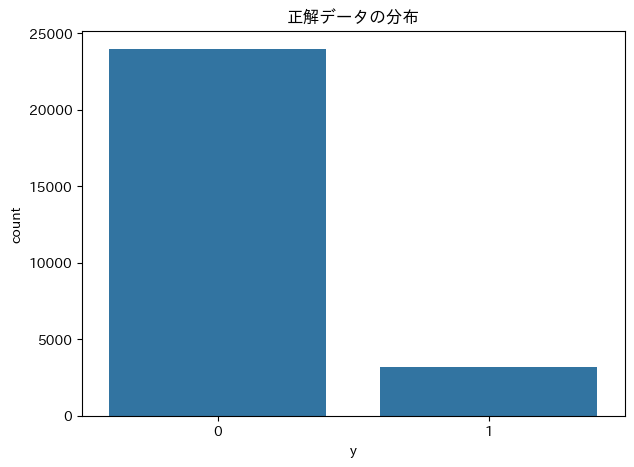

In [102]:
plt.figure(figsize=(7, 5))  #グラフサイズ x,y インチ
sns.countplot(x=train['y'], data=train) #xの値についてgroup by
plt.title('正解データの分布')
plt.show()

次にカテゴリデータを見てみます。

describeの引数にinclude=['O']を渡すことでカテゴリデータの統計値を確認できます。

In [103]:
#カテゴリデータを見るためのdesribe
train.describe(include=['O']) #データ数,値の種類,個数の多い値,一番多い値

,job,marital,education,default,housing,loan,contact,month,poutcome
count,27128,27128,27128,27128,27128,27128,27128,27128,27128
unique,12,3,4,2,2,2,3,12,4
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown
freq,5886,16411,13882,26644,15125,22788,17580,8317,22150


In [104]:
test.describe(include=['O'])

,job,marital,education,default,housing,loan,contact,month,poutcome
count,18083,18083,18083,18083,18083,18083,18083,18083,18083
unique,12,3,4,2,2,2,3,12,4
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown
freq,3846,10803,9320,17752,10005,15179,11705,5449,14809


それでは各特徴量とyとの関係性をグラフで可視化してみましょう。

初めに数値データの相関係数を見てみます。

In [105]:
# 例: 数値列のみを選択する（非数値列は除外）
numerical_cols = train.select_dtypes(include=np.number).columns #数値型のカラム名だけをリストアップ
correlation_matrix = train[numerical_cols].corr() #相関係数を-1.0~1.0までで数値化
print(correlation_matrix)

                id       age   balance       day  duration  campaign  \
id        1.000000 -0.005716 -0.000484  0.002974  0.002705  0.016867   
age      -0.005716  1.000000  0.095343 -0.008518 -0.005309 -0.001340   
balance  -0.000484  0.095343  1.000000  0.002067  0.019923 -0.016295   
day       0.002974 -0.008518  0.002067  1.000000 -0.032453  0.164880   
duration  0.002705 -0.005309  0.019923 -0.032453  1.000000 -0.087771   
campaign  0.016867 -0.001340 -0.016295  0.164880 -0.087771  1.000000   
pdays    -0.004526 -0.025272  0.003613 -0.096889  0.002030 -0.086220   
previous -0.005425  0.002946  0.012483 -0.050009  0.002489 -0.031557   
y        -0.003555  0.020892  0.045826 -0.031058  0.401390 -0.076118   

             pdays  previous         y  
id       -0.004526 -0.005425 -0.003555  
age      -0.025272  0.002946  0.020892  
balance   0.003613  0.012483  0.045826  
day      -0.096889 -0.050009 -0.031058  
duration  0.002030  0.002489  0.401390  
campaign -0.086220 -0.031557 -0.0

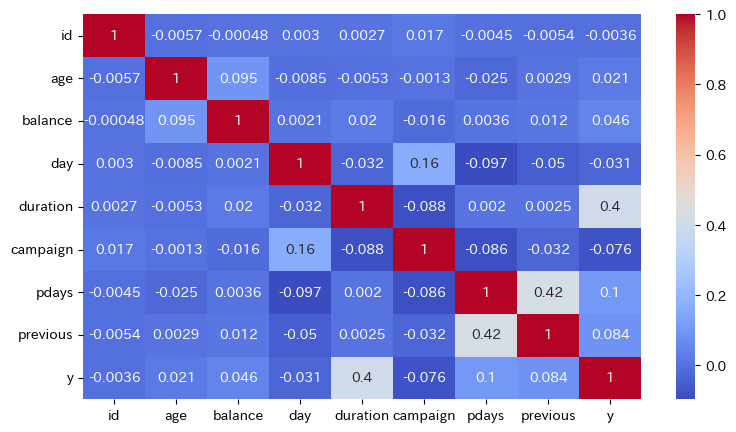

In [106]:
# ヒートマップで可視化
plt.figure(figsize=(9, 5))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap='coolwarm') #ヒートマップ作製(データ自体,相関係数の表示,色の設定)
plt.xticks(rotation=0)
plt.show()

duration, pdays, previousのそれぞれとyとの相関係数が少し高いことが確認できます。

それぞれyへの影響を可視化してみます。

durationのような連続値の可視化には確率密度関数を使用します。

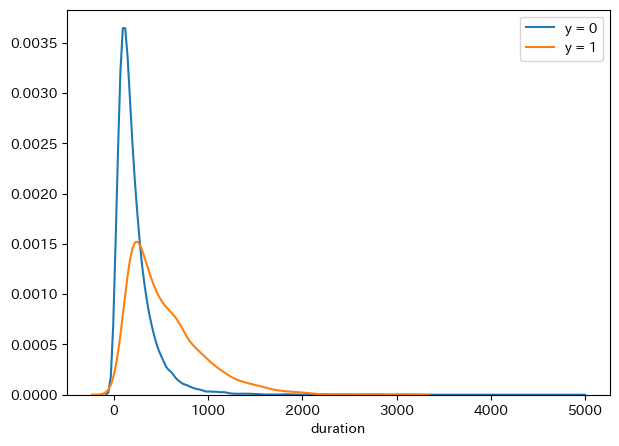

In [107]:
#kdeplotで確率密度関数可視化
plt.figure(figsize=(7, 5))
sns.kdeplot(train[train['y'] == 0]['duration'], label='y = 0') #KDE(カーネル密度推定) 面積を1になるように調整してグラフ化
sns.kdeplot(train[train['y'] == 1]['duration'], label='y = 1')
plt.legend()
plt.ylabel('')
plt.show()

durationの値が高いとyが1となる確率が高くなることがわかります。

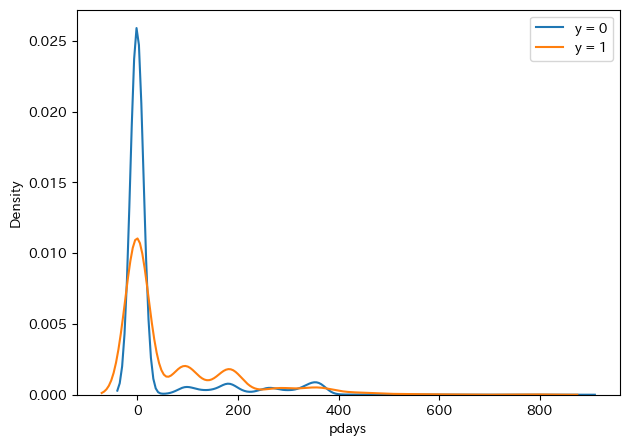

In [108]:
plt.figure(figsize=(7, 5))
sns.kdeplot(train[train['y'] == 0]['pdays'], label='y = 0')
sns.kdeplot(train[train['y'] == 1]['pdays'], label='y = 1')
plt.legend()
plt.show()

In [109]:
# 負の値があるように見えるので確認
train['pdays'].value_counts()

,count
pdays,
-1,22146
182,98
92,89
91,73
183,72
...,...
782,1
424,1
218,1


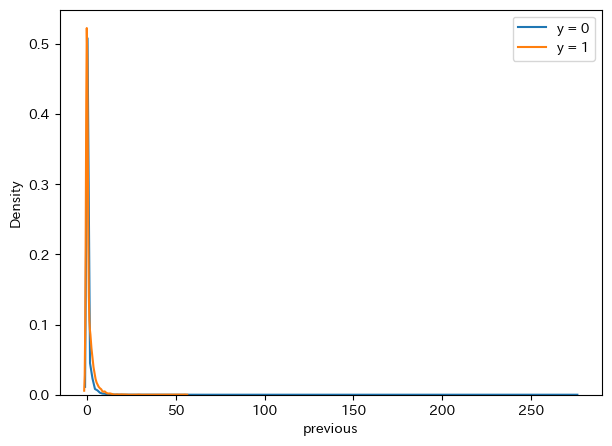

In [110]:
plt.figure(figsize=(7, 5))
sns.kdeplot(train[train['y'] == 0]['previous'], label='y = 0')
sns.kdeplot(train[train['y'] == 1]['previous'], label='y = 1')
plt.legend()
plt.show()

大きく偏ったグラフになりました。

特にpdaysに関してはほとんどが-1であることがわかりました。

それぞれに外れ値を含んでいることが見て取れます。

箱ひげ図でも可視化してみます。

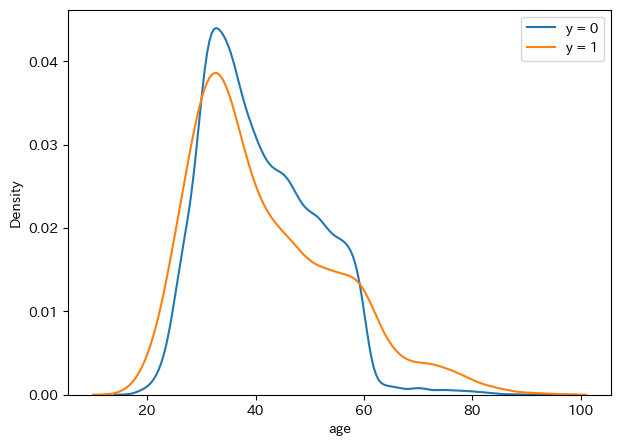

In [111]:
plt.figure(figsize=(7, 5))
sns.kdeplot(train[train['y'] == 0]['age'], label='y = 0')
sns.kdeplot(train[train['y'] == 1]['age'], label='y = 1')
plt.legend()
plt.show()

年齢で変化があるか確認

結果として60以上は効果がありそうだったが職業の定年退職で補えるため効果なし

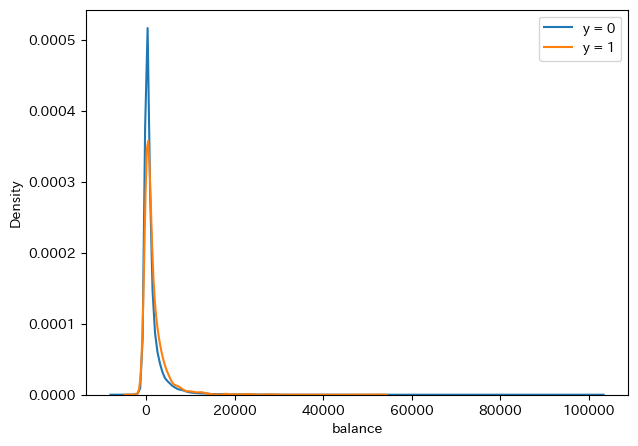

In [112]:
plt.figure(figsize=(7, 5))
sns.kdeplot(train[train['y'] == 0]['balance'], label='y = 0')
sns.kdeplot(train[train['y'] == 1]['balance'], label='y = 1')
plt.legend()
plt.show()

In [113]:
# y=1の人だけの、残高の分布（パーセンタイル）を確認する
y1_balance_desc = train[train['y']==1]['balance'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print(y1_balance_desc)

count     3174.000000
mean      1733.888154
std       3028.712596
min      -3058.000000
10%          2.000000
25%        215.000000
50%        718.500000
75%       2148.250000
90%       4333.000000
95%       6600.950000
99%      13014.000000
max      52587.000000
Name: balance, dtype: float64


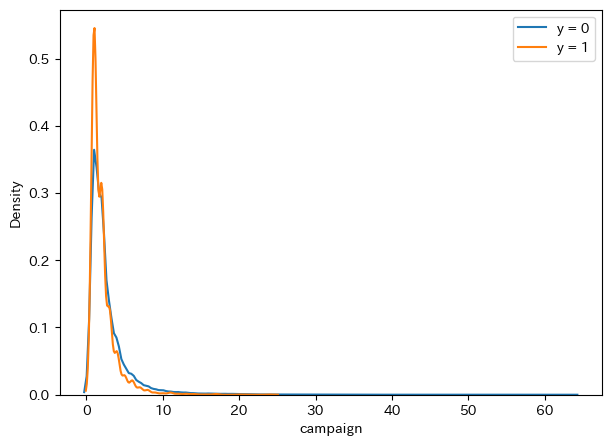

In [114]:
plt.figure(figsize=(7, 5))
sns.kdeplot(train[train['y'] == 0]['campaign'], label='y = 0')
sns.kdeplot(train[train['y'] == 1]['campaign'], label='y = 1')
plt.legend()
plt.show()

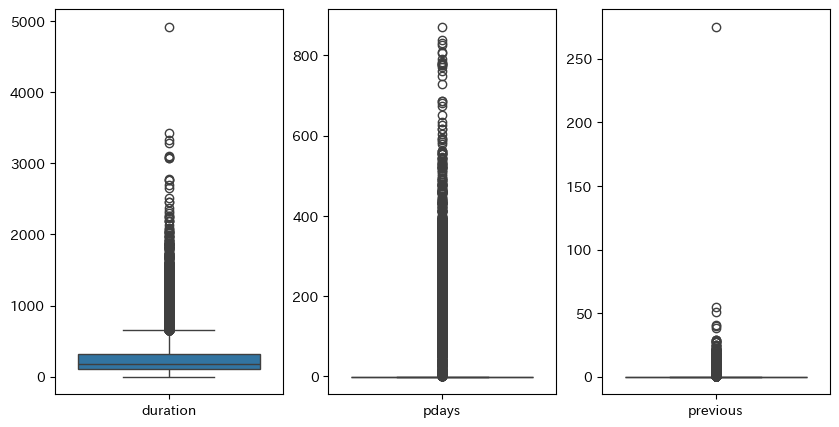

In [115]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1) #1行*3列に分割した1番目に配置する
sns.boxplot(train[['duration']])

plt.subplot(1, 3, 2)
sns.boxplot(train[['pdays']])

plt.subplot(1, 3, 3)
sns.boxplot(train[['previous']])

plt.show()

次にカテゴリデータを見ていきます。

yと関係がありそうな職種とローンの有無を見ていきましょう。

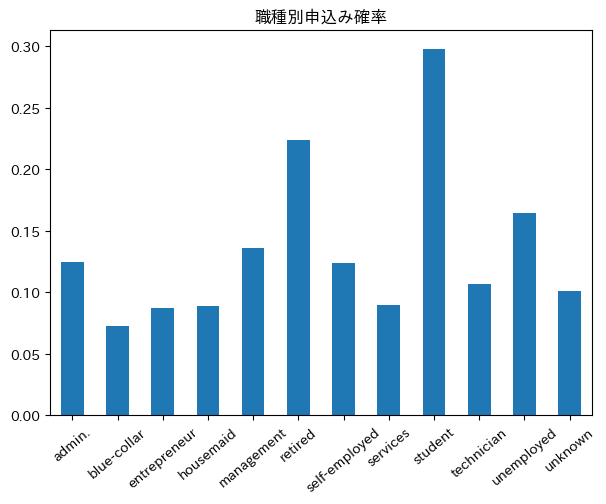

In [116]:
# 職種ごとのyの違い
plt.figure(figsize=(7, 5))
train.groupby('job')['y'].mean().plot.bar() #jobの種類に分けてyの平均値を棒グラフで
plt.xticks(rotation=40) #X軸のラベルを傾け
plt.title('職種別申込み確率')
plt.xlabel('')
plt.show()

学生や引退した人など労働者ではない場合にyの確率が高いことがわかります。

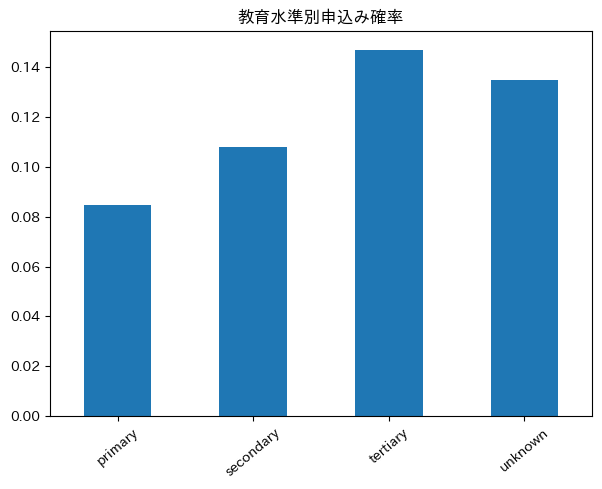

In [117]:
# educationごとのyの違い
plt.figure(figsize=(7, 5))
train.groupby('education')['y'].mean().plot.bar()
plt.xticks(rotation=40)
plt.title('教育水準別申込み確率')
plt.xlabel('')
plt.show()

isnullで欠損地は確認できませんでしたが、job,educationのそれぞれに欠損地のような意味を持つunknownが一定数あることがわかります。

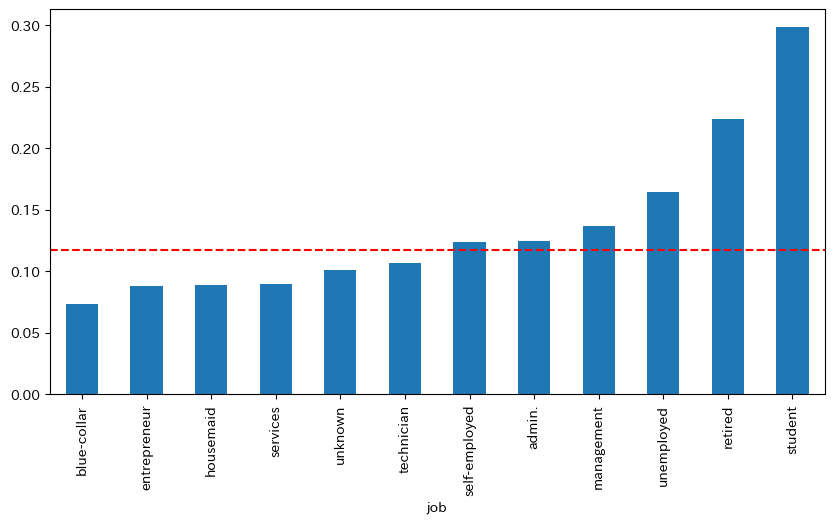

In [118]:
# 職種ごとの成約率を可視化
plt.figure(figsize=(10, 5))
train.groupby('job')['y'].mean().sort_values().plot.bar()
plt.axhline(train['y'].mean(), color='red', linestyle='--') # 全体平均の線
plt.show()

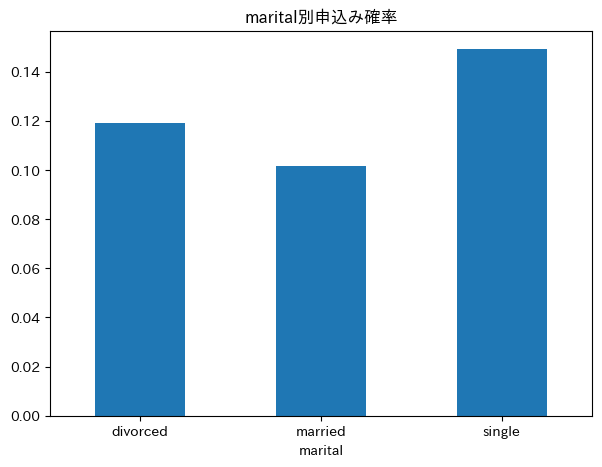

In [119]:
# 既婚かどうかによるyの違い
plt.figure(figsize=(7, 5))
train.groupby('marital')['y'].mean().plot.bar()
plt.title('marital別申込み確率')
plt.xticks(rotation=0)
plt.show()

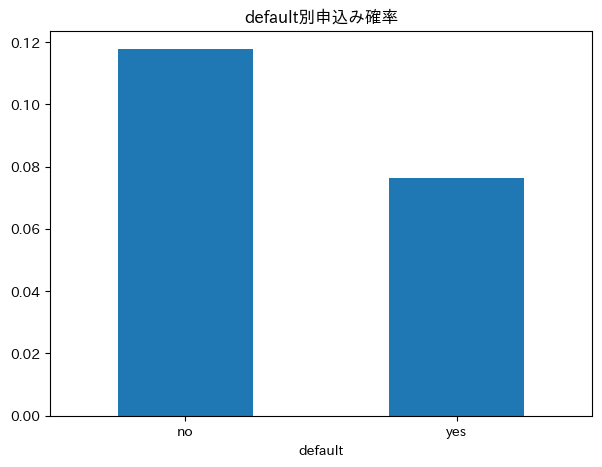

In [120]:
# 債務不履行があるかどうかによるyの違い
plt.figure(figsize=(7, 5))
train.groupby('default')['y'].mean().plot.bar()
plt.title('default別申込み確率')
plt.xticks(rotation=0)
plt.show()

<Axes: >

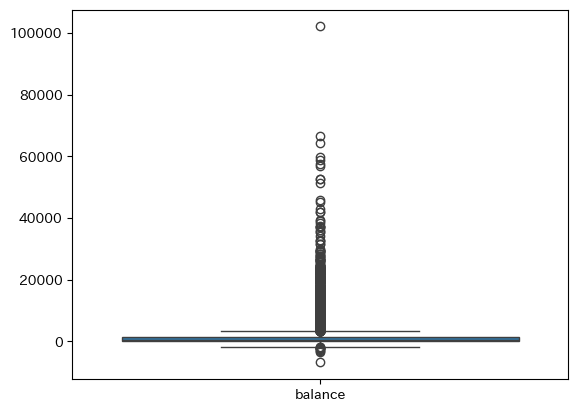

In [121]:
sns.boxplot(train[['balance']])

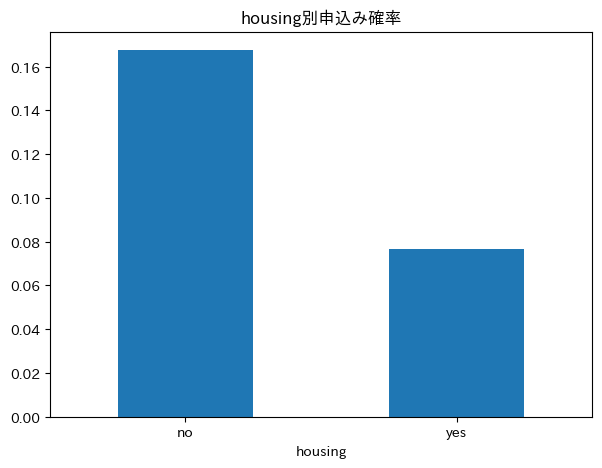

In [122]:
# 住宅ローンの有無によるyの違い
plt.figure(figsize=(7, 5))
train.groupby('housing')['y'].mean().plot.bar()
plt.title('housing別申込み確率')
plt.xticks(rotation=0)
plt.show()

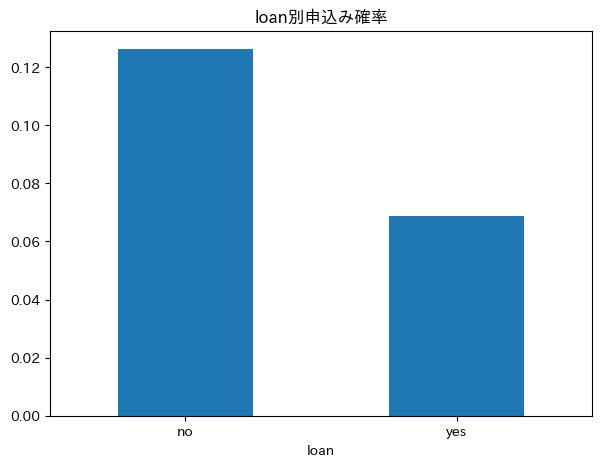

In [123]:
# 個人ローンの有無によるyの違い
plt.figure(figsize=(7, 5))
train.groupby('loan')['y'].mean().plot.bar()
plt.title('loan別申込み確率')
plt.xticks(rotation=0)
plt.show()

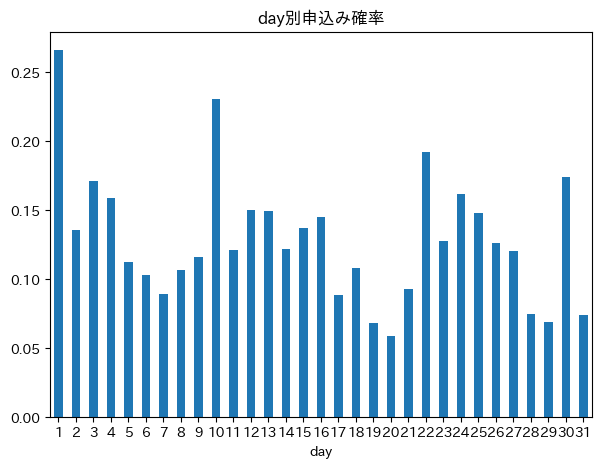

In [124]:
# 個人ローンの有無によるyの違い
plt.figure(figsize=(7, 5))
train.groupby('day')['y'].mean().plot.bar()
plt.title('day別申込み確率')
plt.xticks(rotation=0)
plt.show()

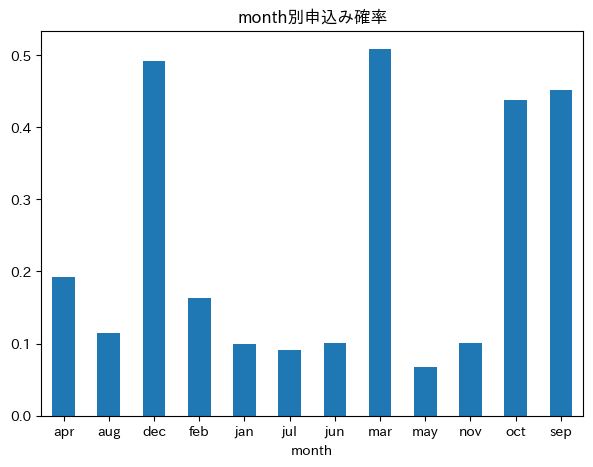

In [125]:
# 個人ローンの有無によるyの違い
plt.figure(figsize=(7, 5))
train.groupby('month')['y'].mean().plot.bar()
plt.title('month別申込み確率')
plt.xticks(rotation=0)
plt.show()

ここまでで、「過去に債務不履行がなく未婚で各種ローンを組んでいなければyが1である確率が高い」という傾向がつかめました。

なんとなくでも、どんな人が申し込むのかイメージすることができたでしょうか。

## 4. データの前処理
目的変数との相関が高かったduration, pdays, previous

そして可視化したjob, education, marital, default, housing, loanを

特徴量として使用してみます。

In [126]:
use_columns = ['month', 'campaign', 'balance', 'duration', 'pdays', 'previous', 'job', 'education', 'marital', 'default', 'housing', 'loan'] #一部のカラムのみ取り出し
y = train['y']
train = train[use_columns]
test = test[use_columns]

In [127]:
train.head()

,month,campaign,balance,duration,pdays,previous,job,education,marital,default,housing,loan
0,apr,1,1756,939,-1,0,blue-collar,secondary,married,no,yes,no
1,feb,10,1443,172,-1,0,entrepreneur,primary,married,no,no,no
2,apr,1,436,567,595,2,management,tertiary,single,no,no,no
3,jan,1,474,423,-1,0,retired,secondary,married,no,no,no
4,apr,1,354,502,9,2,management,tertiary,single,no,no,no


In [128]:
#カテゴリ変数のダミー変数化
train = pd.get_dummies(train, drop_first=True)
test = pd.get_dummies(test, drop_first=True)

In [129]:
# モデルの作成
# n_estimators: 木を何本作るか（まずは100本）
# max_depth: 木の深さ（深すぎると過学習するので、まずは10くらいで試すのがセオリー）
# random_state: 結果を固定するための番号
rf = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42)

## 5. 学習・検証
今回は医療(病気になる確率)やマーケティング(契約率)などのキーワードでよく登場するロジスティック回帰を使用します。

不均衡データにおいて対応しやすい点もメリットです。

In [130]:
# データの分割 学習用データの作成
X_train, X_valid, y_train, y_valid = train_test_split(train, y, test_size=0.25, random_state=82, stratify=y) #分割の割合,分割結果を一定にするためのステータス,答えの割合を一定にするための答えの変数
#練習問題, テスト問題, 練習問題回答, テスト問題回答に分割 練習問題テスト問題の答えの0,1割合は一定

In [131]:

# # 候補となる木の数を設定
# param_grid = {'n_estimators':[50, 100, 200, 300, 500]}

# rf_ = RandomForestClassifier(random_state=42)
# grid_search = GridSearchCV(estimator=rf_, param_grid=param_grid, cv=5)
# grid_search.fit(X_train, y_train)

# print(f"最適な本数: {grid_search.best_params_}")

In [132]:
# 学習
rf.fit(X_train, y_train)

# 予測（確率を出す）
train_prob = rf.predict_proba(X_train)[:, 1]
valid_prob = rf.predict_proba(X_valid)[:, 1]

In [133]:
# print('train score : ', accuracy_score(y_train, train_prob))
# print('valid score : ', accuracy_score(y_valid, valid_prob))

#AUCスコアでの精度
print("train AUC:", roc_auc_score(y_train, train_prob))
print("valid AUC:", roc_auc_score(y_valid, valid_prob))

train AUC: 0.9387064922818731
valid AUC: 0.9007237817364369


## 6.予測・結果の提出

In [134]:
# testデータの予測
predict = rf.predict_proba(test)[:, 1]

In [135]:
# submit_sampleの読み込み、提出フォームの作成
submit = pd.read_csv('submit_sample.csv', header=None)
submit[1] = predict
submit.to_csv('submission_tutorial.csv', header=None,index=False)

In [136]:
submit.head()

,0,1
0,1,0.493370
1,2,0.506002
2,3,0.025534
3,4,0.020424
4,5,0.078827


### 最後に
結果は0.7985...でした。

このチュートリアルから発展させていくには、まず学習に利用する説明変数の数を増やすところから初めてみましょう。

またnullはありませんでしたが、unknownというデータが含まれていましたので、最頻値や他の説明変数から傾向を掴み置き換えてみるのもいいかもしれません。

その際には目的変数と説明変数の関係性についてグラフなどを用いて確認し、データセットの背景を掴んでみてください。
